# Section 1: Notebook Setup & Imports

This section initializes the notebook environment, sets up path resolution to import project utilities, and imports necessary libraries for modeling, data handling, and evaluation. We also verify CUDA availability for GPU-accelerated XGBoost training.



In [1]:
import os
import sys
import random
from pathlib import Path
import time
import pickle
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import torch
import xgboost as xgb
from xgboost import XGBRegressor

# Resolve project root path and append to sys.path
PROJECT_ROOT = os.path.abspath("../../../")
print(f"Project root: {PROJECT_ROOT}")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# Import metrics dashboard from project utilities
try:
    from u_dashboard.dashboard import metrics_dashboard
    print("Imported dashboard from u_dashboard.dashboard")
except ImportError as e:
    try:
        from Models.Utils.dashboard import metrics_dashboard
        print("Imported dashboard from Models.Utils")
    except ImportError as e2:
        from Utils.dashboard import metrics_dashboard
        print("Imported dashboard from local Utils")

import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
print(f"Random seed set to {SEED}")

# Setup plotting style
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# Verify CUDA/GPU availability for XGBoost
try:
    dummy = xgb.XGBRegressor(n_estimators=1, device="cuda")
    dummy.fit(np.array([[1.0]]), np.array([1.0]))
    XGB_DEVICE = "cuda"
    print("XGBoost CUDA support verified and enabled.")
except Exception as e:
    XGB_DEVICE = "cpu"
    print(f"XGBoost CUDA dummy test failed ({e}). Falling back to CPU.")

print("Environment setup complete.")



Project root: C:\Users\pan\Documents\GitHub\MDR-Project
Imported dashboard from u_dashboard.dashboard
Random seed set to 42
XGBoost CUDA support verified and enabled.
Environment setup complete.


# Section 2: Data Loading & Preprocessing

This section loads the train, validation, and test splits for the `derived_8.1` dataset. We concatenate the train and validation sets to form the `trainval` split for model training, and import the regime thresholds ($T_1$, $T_2$) and the lists of selected features for overall and regime-specific modeling from `dataset_metadata.py`.

In [2]:
# Define path configurations
TRAIN_PATH = os.path.join(PROJECT_ROOT, "data/splits/derived_8.1/train.csv")
VAL_PATH = os.path.join(PROJECT_ROOT, "data/splits/derived_8.1/val.csv")
TEST_PATH = os.path.join(PROJECT_ROOT, "data/splits/derived_8.1/test.csv")

# Load dataset splits
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Dataset splits loaded:")
print(f"  train: {train_df.shape}")
print(f"  val:   {val_df.shape}")
print(f"  test:  {test_df.shape}")

# Concatenate train and val for training+validation
trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)
print(f"  trainval (concatenated): {trainval_df.shape}")

# Import metadata and configuration constants from dataset_metadata.py using importlib
import importlib.util
metadata_path = os.path.join(PROJECT_ROOT, "data/splits/derived_8.1/dataset_metadata.py")
spec = importlib.util.spec_from_file_location("dataset_metadata", metadata_path)
dataset_metadata = importlib.util.module_from_spec(spec)
spec.loader.exec_module(dataset_metadata)

T1 = dataset_metadata.T1
T2 = dataset_metadata.T2
DRY_THRESHOLD = dataset_metadata.DRY_THRESHOLD
WET_THRESHOLD = dataset_metadata.WET_THRESHOLD
OVERALL_SELECTED_FEATURES = dataset_metadata.OVERALL_SELECTED_FEATURES
DRY_SELECTED_FEATURES = dataset_metadata.DRY_SELECTED_FEATURES
TRANSITION_SELECTED_FEATURES = dataset_metadata.TRANSITION_SELECTED_FEATURES
WET_SELECTED_FEATURES = dataset_metadata.WET_SELECTED_FEATURES

TARGET_COL = "soil_moisture_5cm"

print("\nThresholds and Selected Features loaded successfully:")
print(f"  Regime Thresholds: T1={T1}, T2={T2}")
print(f"  Overall Selected Features:    {len(OVERALL_SELECTED_FEATURES)}")
print(f"  Dry Selected Features:        {len(DRY_SELECTED_FEATURES)}")
print(f"  Transition Selected Features: {len(TRANSITION_SELECTED_FEATURES)}")
print(f"  Wet Selected Features:        {len(WET_SELECTED_FEATURES)}")

Dataset splits loaded:
  train: (16462, 499)
  val:   (7714, 499)
  test:  (10599, 499)
  trainval (concatenated): (24176, 499)

Thresholds and Selected Features loaded successfully:
  Regime Thresholds: T1=0.16, T2=0.25
  Overall Selected Features:    40
  Dry Selected Features:        40
  Transition Selected Features: 40
  Wet Selected Features:        40


# Section 3: Model 1 - No Gating (Single Global Model)

This section trains a single global XGBoost model on the concatenated `trainval` split using the `OVERALL_SELECTED_FEATURES`. We evaluate the model's performance on the test set using the default evaluation metrics (R?, MAE, and bias).

In [3]:
# Define global model parameters matching v25 / v19.3 configuration
XGB_PARAMS_GLOBAL = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=2,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
    device=XGB_DEVICE
)

print("XGBoost Global Model Parameters initialized:")
print(f"  device: {XGB_PARAMS_GLOBAL['device']}")

# Train global model
print("\nTraining XGBoost Global Model...")
start_time = time.time()
xgb_global = XGBRegressor(**XGB_PARAMS_GLOBAL)
xgb_global.fit(
    trainval_df[OVERALL_SELECTED_FEATURES],
    trainval_df[TARGET_COL],
    verbose=0
)
print(f"Training completed in {time.time() - start_time:.2f} seconds.")

# Predict on the test split
y_test = np.asarray(test_df[TARGET_COL]).ravel()
pred_global = np.asarray(xgb_global.predict(test_df[OVERALL_SELECTED_FEATURES])).ravel()

# Display performance metrics using the project dashboard
metrics_dashboard(
    y_test,
    pred_global,
    name="Model 1 | Single Global XGBoost Model (No Gating)"
)

# Extract and print individual temporal performance metrics
metrics_global_dict = metrics_dashboard(y_test, pred_global, show=False, return_dict=True)
print("\n===== GLOBAL MODEL METRICS =====")
print(f"R? Score:  {metrics_global_dict['r2']:.5f}")
print(f"MAE:       {metrics_global_dict['mae']:.5f}")
print(f"Bias:      {metrics_global_dict['bias']:.5f}")

XGBoost Global Model Parameters initialized:
  device: cuda

Training XGBoost Global Model...


Training completed in 35.41 seconds.



===== GLOBAL MODEL METRICS =====
R? Score:  0.41598
MAE:       0.06756
Bias:      -0.02824


# Section 4: Model 2 - Regime Specialists (Oracle Hard Gating)

In this section, we implement **Oracle Hard Gating**. We split the combined training and validation dataset (`trainval_df`) into three disjoint subsets based on the true target soil moisture (`soil_moisture_5cm`) using the valley-calibrated thresholds $T_1 = 0.16$ and $T_2 = 0.25$:
- **Dry Regime**: $\text{SM} < 0.16$
- **Transition Regime**: $0.16 \le \text{SM} < 0.25$
- **Wet Regime**: $\text{SM} \ge 0.25$

Three specialist models (`xgb_dry`, `xgb_transition`, `xgb_wet`) are trained on their respective subsets using their respective optimized features (`DRY_SELECTED_FEATURES`, `TRANSITION_SELECTED_FEATURES`, `WET_SELECTED_FEATURES`). We then evaluate each specialist model on its corresponding slice of the test set.

In [4]:
# Define parameter dictionaries for each regime specialist
XGB_PARAMS_DRY = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=2,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
    device=XGB_DEVICE
)

XGB_PARAMS_TRANSITION = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    max_depth=7,
    min_child_weight=5,
    subsample=0.9,
    colsample_bytree=0.85,
    n_estimators=8000,
    learning_rate=0.03,
    reg_lambda=3.0,
    reg_alpha=0.05,
    device=XGB_DEVICE
)

XGB_PARAMS_WET = dict(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    max_depth=10,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=0.9,
    n_estimators=6000,
    learning_rate=0.03,
    reg_lambda=0.3,
    reg_alpha=0.0,
    device=XGB_DEVICE
)

print("XGBoost Specialist Parameters initialized.")

# Generate regime masks for trainval
y_trainval = np.asarray(trainval_df[TARGET_COL]).ravel()
mask_dry_tv = y_trainval < T1
mask_transition_tv = (y_trainval >= T1) & (y_trainval < T2)
mask_wet_tv = y_trainval >= T2

print("\nTrainval Split Regime Distribution:")
print(f"  Dry:        {mask_dry_tv.sum():,}")
print(f"  Transition: {mask_transition_tv.sum():,}")
print(f"  Wet:        {mask_wet_tv.sum():,}")

# 1. Train Dry Specialist
print("\nTraining Dry Specialist model...")
start_time = time.time()
xgb_dry = XGBRegressor(**XGB_PARAMS_DRY)
xgb_dry.fit(
    trainval_df.loc[mask_dry_tv, DRY_SELECTED_FEATURES],
    trainval_df.loc[mask_dry_tv, TARGET_COL],
    verbose=0
)
print(f"Dry Specialist training completed in {time.time() - start_time:.2f} seconds.")

# 2. Train Transition Specialist
print("Training Transition Specialist model...")
start_time = time.time()
xgb_transition = XGBRegressor(**XGB_PARAMS_TRANSITION)
xgb_transition.fit(
    trainval_df.loc[mask_transition_tv, TRANSITION_SELECTED_FEATURES],
    trainval_df.loc[mask_transition_tv, TARGET_COL],
    verbose=0
)
print(f"Transition Specialist training completed in {time.time() - start_time:.2f} seconds.")

# 3. Train Wet Specialist
print("Training Wet Specialist model...")
start_time = time.time()
xgb_wet = XGBRegressor(**XGB_PARAMS_WET)
xgb_wet.fit(
    trainval_df.loc[mask_wet_tv, WET_SELECTED_FEATURES],
    trainval_df.loc[mask_wet_tv, TARGET_COL],
    verbose=0
)
print(f"Wet Specialist training completed in {time.time() - start_time:.2f} seconds.")
print("All specialist models successfully trained.")

XGBoost Specialist Parameters initialized.

Trainval Split Regime Distribution:
  Dry:        9,557
  Transition: 5,307
  Wet:        9,312

Training Dry Specialist model...


Dry Specialist training completed in 30.63 seconds.
Training Transition Specialist model...


Transition Specialist training completed in 40.68 seconds.
Training Wet Specialist model...


Wet Specialist training completed in 13.16 seconds.
All specialist models successfully trained.


In [5]:
# Generate regime masks for the test set (Oracle Gating)
mask_dry_test = y_test < T1
mask_transition_test = (y_test >= T1) & (y_test < T2)
mask_wet_test = y_test >= T2

print("Test Split Regime Distribution:")
print(f"  Dry:        {mask_dry_test.sum():,}")
print(f"  Transition: {mask_transition_test.sum():,}")
print(f"  Wet:        {mask_wet_test.sum():,}")

# Predict on the full test dataset using each specialist
pred_dry_test = np.asarray(xgb_dry.predict(test_df[DRY_SELECTED_FEATURES])).ravel()
pred_transition_test = np.asarray(xgb_transition.predict(test_df[TRANSITION_SELECTED_FEATURES])).ravel()
pred_wet_test = np.asarray(xgb_wet.predict(test_df[WET_SELECTED_FEATURES])).ravel()

# Evaluate each specialist on its respective test regime slice
print("\n===== REGIME SPECIALIST PERFORMANCE (ON TARGET SLICES) =====")

# Dry Specialist on Dry Test Slice
print("\n--- 1. Dry Specialist (Evaluating on SM < T1) ---")
metrics_dashboard(
    y_test[mask_dry_test],
    pred_dry_test[mask_dry_test],
    name="Dry Specialist Model (Dry Slice)"
)

# Transition Specialist on Transition Test Slice
print("\n--- 2. Transition Specialist (Evaluating on T1 <= SM < T2) ---")
metrics_dashboard(
    y_test[mask_transition_test],
    pred_transition_test[mask_transition_test],
    name="Transition Specialist Model (Transition Slice)"
)

# Wet Specialist on Wet Test Slice
print("\n--- 3. Wet Specialist (Evaluating on SM >= T2) ---")
metrics_dashboard(
    y_test[mask_wet_test],
    pred_wet_test[mask_wet_test],
    name="Wet Specialist Model (Wet Slice)"
)

Test Split Regime Distribution:
  Dry:        5,054
  Transition: 2,471
  Wet:        3,074



===== REGIME SPECIALIST PERFORMANCE (ON TARGET SLICES) =====

--- 1. Dry Specialist (Evaluating on SM < T1) ---



--- 2. Transition Specialist (Evaluating on T1 <= SM < T2) ---



--- 3. Wet Specialist (Evaluating on SM >= T2) ---


# Section 5: Model 3 - Combined Oracle Performance & Residuals Plot

In this final section, we evaluate the **Combined Oracle Hard Gated Model**. For each sample in the test set, we route the prediction to the corresponding regime specialist based on the *true* target soil moisture of that sample:
- If $y_{true} < 0.16$, we select the Dry specialist prediction.
- If $0.16 \le y_{true} < 0.25$, we select the Transition specialist prediction.
- If $y_{true} \ge 0.25$, we select the Wet specialist prediction.

We evaluate this combined prediction set against the test labels and generate the "Residuals vs True SM | Hard Gated (Oracle)" diagnostic plot.

In [6]:
# Route predictions using oracle routing masks
pred_combined = np.zeros_like(y_test, dtype=float)
pred_combined[mask_dry_test] = pred_dry_test[mask_dry_test]
pred_combined[mask_transition_test] = pred_transition_test[mask_transition_test]
pred_combined[mask_wet_test] = pred_wet_test[mask_wet_test]

# Evaluate the combined oracle performance
metrics_dashboard(
    y_test,
    pred_combined,
    name="Model 3 | Combined Oracle Hard Gated Model (MoE)"
)

metrics_combined_dict = metrics_dashboard(y_test, pred_combined, show=False, return_dict=True)
print("\n===== COMBINED ORACLE MODEL METRICS =====")
print(f"R? Score:  {metrics_combined_dict['r2']:.5f}")
print(f"MAE:       {metrics_combined_dict['mae']:.5f}")
print(f"Bias:      {metrics_combined_dict['bias']:.5f}")


===== COMBINED ORACLE MODEL METRICS =====
R? Score:  0.85270
MAE:       0.03552
Bias:      -0.01791


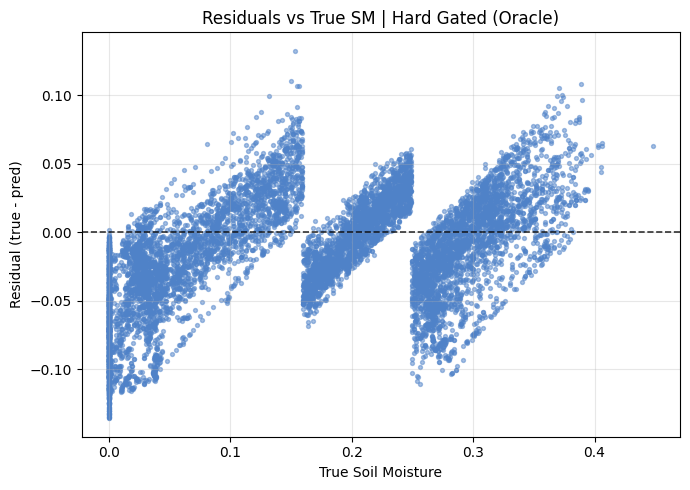

In [7]:
# Compute residuals
residuals = y_test - pred_combined

# Create "Residuals vs True SM | Hard Gated (Oracle)" scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test, residuals, s=8, alpha=0.5, color='#4f82c8')
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
plt.xlabel("True Soil Moisture")
plt.ylabel("Residual (true - pred)")
plt.title("Residuals vs True SM | Hard Gated (Oracle)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()